In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import pickle

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import tilt_distance_Li, plot_tilt_method, bearing


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)

sample_eddies = [75, 471, 951, 1996, 31, 221, 1774, 2399]
with open('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl', 'rb') as f:
    dic_vert = pickle.load(f)
dic_sample = {}
for eddy in sample_eddies:
    dic_sample[f'Eddy{eddy}'] = dic_vert[f'Eddy{eddy}']


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]

# Unique colors for each eddy
colors = [c for i, c in enumerate(plt.get_cmap("tab10").colors) if i != 7]


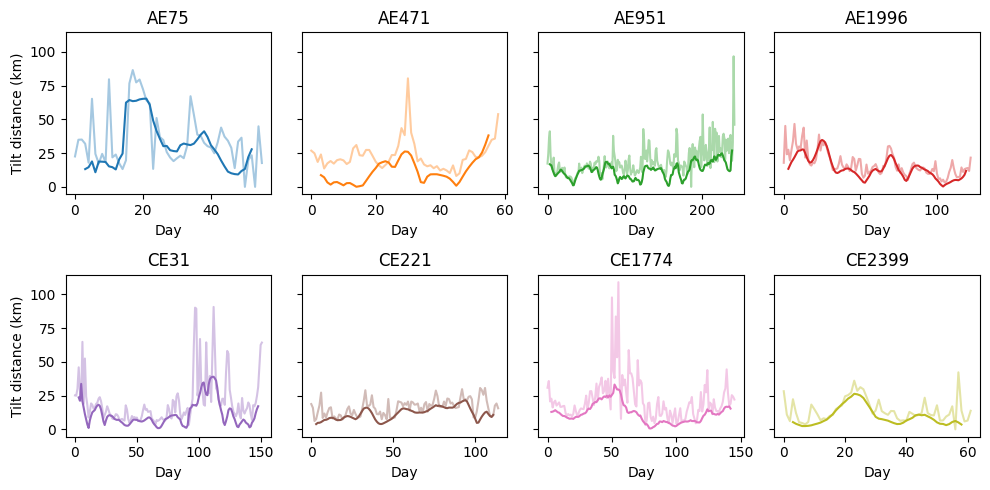

In [4]:
fig, axs = plt.subplots(2, 4, figsize=(10, 5), sharey=True)

for e, eddy in enumerate(dic_sample.keys()):
    ax = axs[e // 4, e % 4]
    dic = dic_sample[eddy]
    days = sorted(dic.keys())
    TDis = []
    for day in days:
        df = dic[day].copy()
        if len(df):
            df = df[df.Depth.abs() < 1e3]
            td, th, _ = tilt_distance_Li(df.xc.values, df.yc.values, df.Depth.abs().values)
            TDis.append(td)
        else:
            TDis.append(np.nan)
    ax.plot(range(len(TDis)), TDis, color=colors[e % 10], alpha=.4)
    df = df_eddies[df_eddies.Eddy==int(eddy[4:])]
    ax.plot(np.arange(len(df)), df.TiltDis, color=colors[e])
    cyc = df_eddies[df_eddies.Eddy==int(eddy[4:])].iloc[0].Cyc
    ax.set_title(f'{cyc}{int(eddy[4:])}')
    ax.set_xlabel('Day')
    # ax.axhline(y=10, color='r')
axs[0,0].set_ylabel('Tilt distance (km)')
axs[1,0].set_ylabel('Tilt distance (km)')

plt.tight_layout()


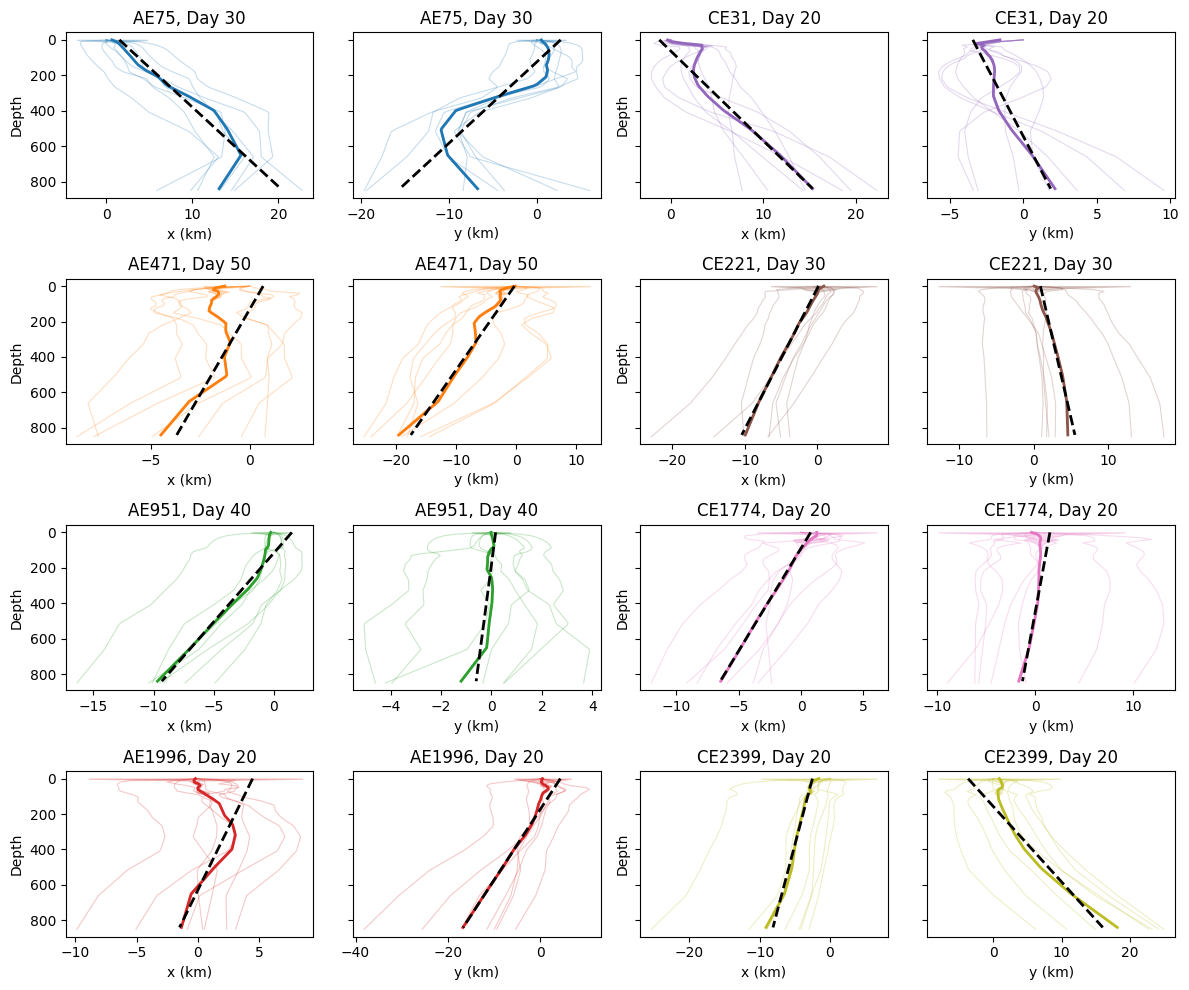

In [5]:
fig, axs = plt.subplots(4, 4, figsize=(12, 10), sharey=True)

ref_days = [30, 50, 40, 20, 20, 30, 20, 20]

for e, (eddy, ref_day) in enumerate(zip(sample_eddies, ref_days)):

    row = e % 4
    col = (e // 4) * 2

    ax_x = axs[row, col]
    ax_y = axs[row, col + 1]

    out = plot_tilt_method(
        dic_all=dic_sample,
        eddy=eddy,
        ref_day_idx=ref_day,
        ax_x=ax_x,
        ax_y=ax_y,
        num=6,
        depth_int=10,
        max_depth=1000,
        min_depth_range=200,
        color=colors[e],
        show=False
    )

    if out[0] is None:
        ax_x.text(0.5, 0.5, f'Eddy {eddy}\nnot measurable',
                  ha='center', va='center', transform=ax_x.transAxes)
        ax_y.text(0.5, 0.5, f'Eddy {eddy}\nnot measurable',
                  ha='center', va='center', transform=ax_y.transAxes)
        continue

    cyc = df_eddies[df_eddies.Eddy==eddy].iloc[0].Cyc
    ax_x.set_title(f'{cyc}{eddy}, Day {ref_day}')
    ax_y.set_title(f'{cyc}{eddy}, Day {ref_day}')
    ax_x.get_legend().remove()
    ax_x.set_xlabel('x (km)'); ax_y.set_xlabel('y (km)')
axs[0,0].invert_yaxis()

for ax in axs[:, 0]:
    ax.set_ylabel('Depth')

# for ax in axs[-1, :]:
#     ax.set_xlabel('Displacement')

plt.tight_layout()
plt.show()


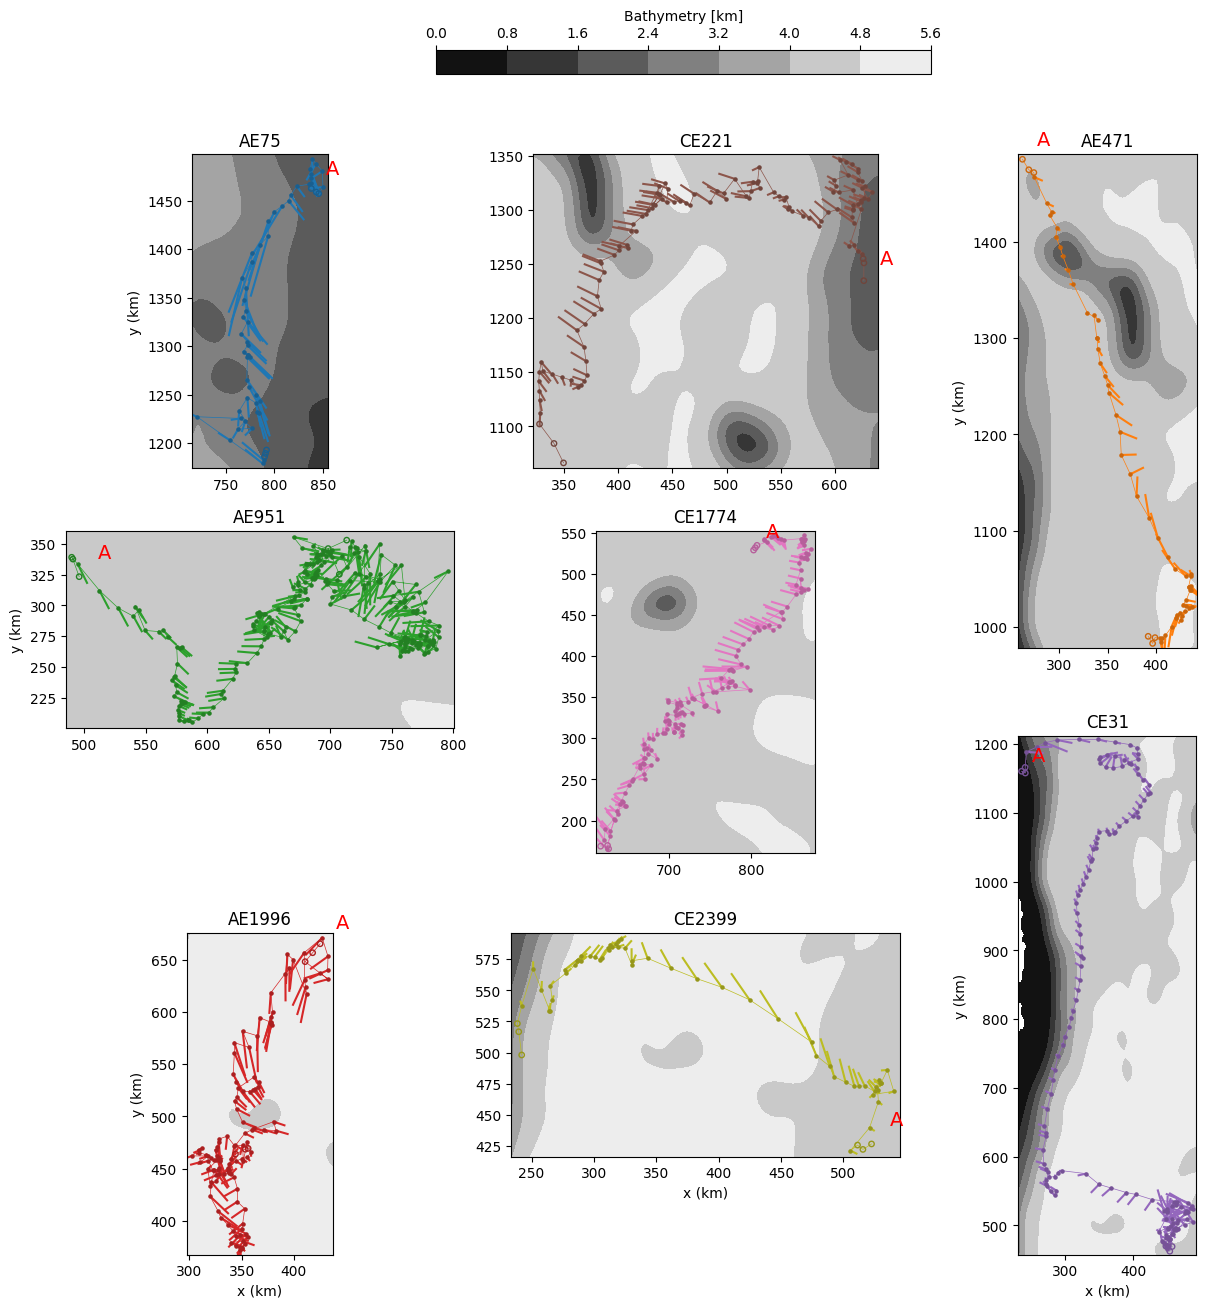

In [6]:
def point_b(a, r, theta_deg):
    theta_rad = np.radians(theta_deg)
    dx = r * np.sin(theta_rad)
    dy = r * np.cos(theta_rad)
    return a[0] - dx, a[1] - dy

from matplotlib.colors import to_rgb
def darken(color, factor=0.7):
    r, g, b = to_rgb(color)
    return (r*factor, g*factor, b*factor)

fig = plt.figure(figsize=(13, 13), constrained_layout=True)
gs = fig.add_gridspec(6, 3)

gap = 5
mappable = None
s = 5

# slots for all non-special eddies on a 6x3 grid (left two columns)
# roughly mimics a 3x2 layout: rows 0,2,4
normal_slots = [
    (0, 0), (2, 0), (4, 0),
    (0, 1), (2, 1), (4, 1),
]

k = 0
axes_list = []
for e, eddy in enumerate(sample_eddies):

    # eddy 1 and 4 get tall panels in the right column
    if e == 1:
        ax = fig.add_subplot(gs[0:3, 2])   # top-right, 1.5 "rows" tall
        axes_list.append(ax)
        col = 2
        row = 0
        is_tall = True
        ax.set_ylabel('y (km)')
    elif e == 4:
        ax = fig.add_subplot(gs[3:6, 2])   # bottom-right, 1.5 "rows" tall
        axes_list.append(ax)
        col = 2
        row = 4
        is_tall = True
        ax.set_xlabel('x (km)')
        ax.set_ylabel('y (km)')
    else:
        row, col = normal_slots[k]
        k += 1
        ax = fig.add_subplot(gs[row:row+2, col])
        axes_list.append(ax)
        is_tall = False

    df = df_eddies[df_eddies.Eddy == eddy]
    m = ax.contourf(X_grid, Y_grid, np.where(mask_rho, h/1e3, np.nan), cmap='gray')
    if mappable is None:
        mappable = m

    df_eddy = df_eddies[df_eddies.Eddy == eddy]
    ax.plot(df_eddy.xc, df_eddy.yc, color=colors[e], linewidth=.5, zorder=1)

    for d, day in enumerate(df['Day'].unique()):
        data = df[df.Day == day]
        tilt_dis = data.iloc[0].TiltDis
        tilt_dir = data.iloc[0].TiltDir

        plot_data = df_eddies[(df_eddies.Eddy == eddy) & (df_eddies['Day'] == int(day))]
        x0, y0 = plot_data.iloc[0].xc, plot_data.iloc[0].yc
        xb, yb = point_b([x0, y0], tilt_dis, (tilt_dir - 20) % 360)

        ax.plot([x0, xb], [y0, yb], color=colors[e], zorder=2)

        cyc = df_eddies[df_eddies.Eddy == eddy].Cyc.iloc[0]
        if d == 0:
            ax.plot([x0, xb], [y0, yb], color=colors[e], zorder=2,
                    label=f'{cyc}{eddy}')

        if np.isnan(tilt_dis):
            ax.scatter(x0, y0, color=darken(colors[e % len(colors)], 0.8),
                       s=15, zorder=3, facecolors='none')
        else:
            ax.scatter(x0, y0, color=darken(colors[e % len(colors)], 0.8),
                       s=s, zorder=3)
    if eddy==1602:
        a, b = -1.5, -1.5
    elif eddy==1780:
        a, b = 1, 0
    elif eddy==182:
        a, b = -1.5, 0
    elif eddy==871:
        a, b = .5, 0
    else:
        a, b = 1, 1
        
    ax.text(df_eddy.iloc[0].xc+a*15, df_eddy.iloc[0].yc+b*15, 'A',
            color='r', fontsize=14)
    cyc = df_eddies[df_eddies.Eddy==eddy].iloc[0].Cyc
    ax.set_aspect('equal', adjustable='box'); ax.set_title(f'{cyc}{eddy}')
    ax.set_xlim(df_eddy.xc.min() - gap, df_eddy.xc.max() + gap)
    ax.set_ylim(df_eddy.yc.min() - gap, df_eddy.yc.max() + gap)

    # axis labels: left column gets y, bottom band gets x
    if col == 0:
        ax.set_ylabel('y (km)')
    # bottom "row" for small plots (row==4) and the lower tall panel (eddy 4)
    if (not is_tall and row == 4) or (is_tall and e == 4):
        ax.set_xlabel('x (km)')

cbar = fig.colorbar(mappable, ax=axes_list, location='top', shrink=0.4)
cbar.set_label('Bathymetry [km]')


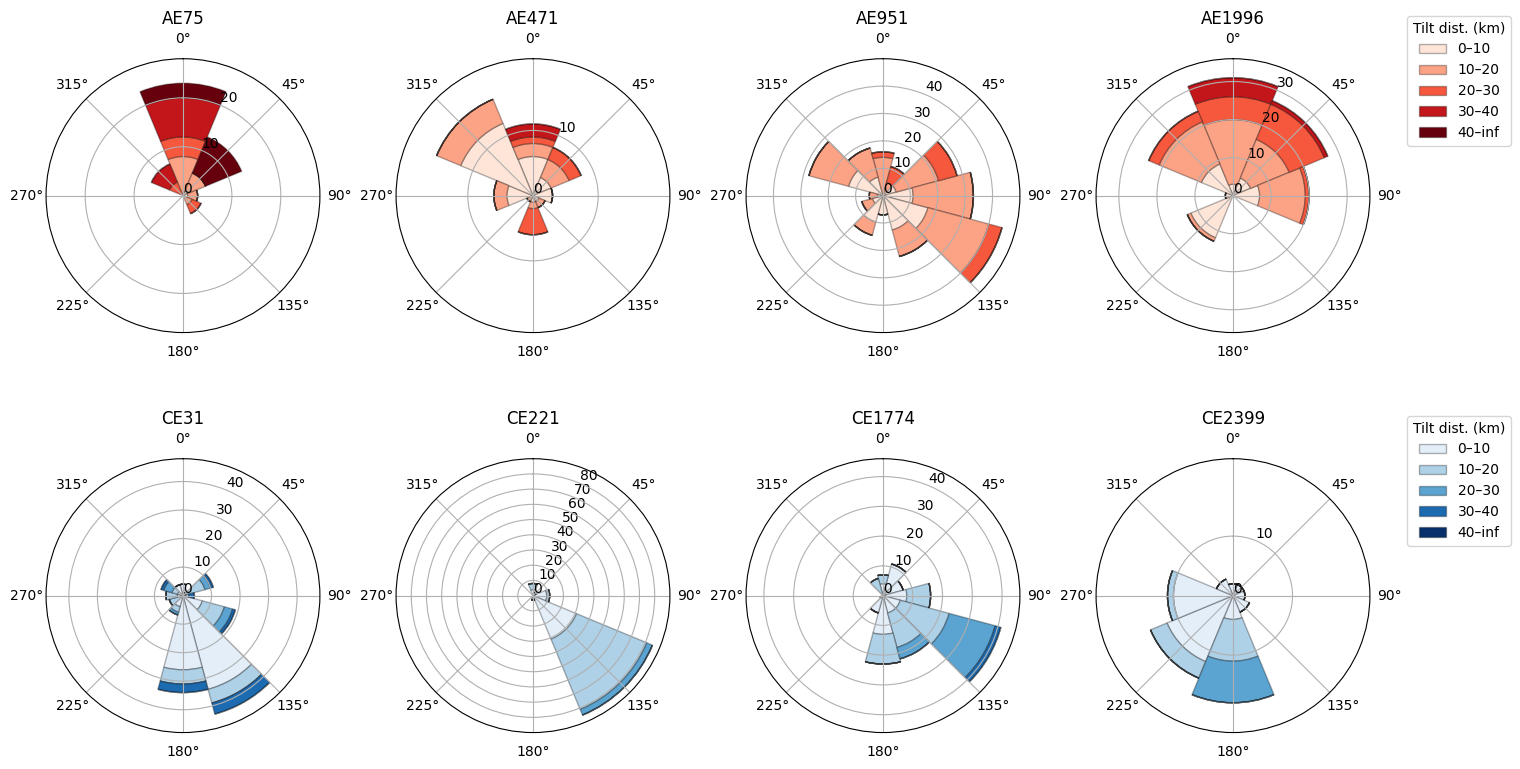

In [7]:
def choose_dir_bins_cardinal(*dfs, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=8):
    candidates = np.array([4, 6, 8, 9, 10, 12, 15, 16, 18, 20, 24, 30, 36, 45, 60, 72])
    candidates = candidates[(candidates >= min_bins) & (candidates <= max_bins)]
    candidates = candidates[candidates % 4 == 0]

    Ns = []
    for df in dfs:
        x = df[col].to_numpy()
        x = x[np.isfinite(x)]
        Ns.append(x.size)
    N = min(Ns) if Ns else 0

    if N == 0 or candidates.size == 0:
        k = 16
    else:
        k0 = int(np.ceil(2 * N ** (1/3)))
        k = candidates[np.argmin(np.abs(candidates - k0))]
        while k > candidates.min() and (N / k) < min_avg_per_sector:
            k = candidates[candidates < k].max()

    dir_bins = np.linspace(0.0, 360.0, k + 1)
    shift = 180.0 / k
    return dir_bins, shift

# ---- per-eddy windroses (bins chosen per panel) ----
fig, axs = plt.subplots(
    2, 4, figsize=(14, 8),
    subplot_kw={'projection': 'polar'},
    constrained_layout=True
)
axs = axs.flatten()

sample_eddies_8 = sample_eddies[:8]
mag_bins = [0, 10, 20, 30, 40, np.inf]

colors_AE = plt.cm.Reds(np.linspace(0.1, 1, len(mag_bins) - 1))
colors_CE = plt.cm.Blues(np.linspace(0.1, 1, len(mag_bins) - 1))

for ax, eddy in zip(axs, sample_eddies_8):
    df = df_eddies[df_eddies.Eddy == eddy].copy()

    directions = np.mod(df.TiltDir.to_numpy(), 360.0)
    magnitudes = df.TiltDis.to_numpy()
    m = np.isfinite(directions) & np.isfinite(magnitudes)
    directions = directions[m]
    magnitudes = magnitudes[m]

    cyc = df.iloc[0].Cyc if len(df) else ""
    colorss = colors_AE if cyc == "AE" else colors_CE

    # --- choose direction bins for THIS eddy only ---
    dir_bins, dir_shift = choose_dir_bins_cardinal(df, col='TiltDir', min_bins=8, max_bins=36, min_avg_per_sector=6)
    k = len(dir_bins) - 1
    binw_deg = 360.0 / k
    angles = np.deg2rad(np.arange(k) * binw_deg)
    width = np.deg2rad(binw_deg)

    directions_s = np.mod(directions + dir_shift, 360.0)
    dir_idx = np.digitize(directions_s, dir_bins, right=False) - 1
    mag_idx = np.digitize(magnitudes, mag_bins, right=False) - 1

    counts = np.zeros((len(mag_bins) - 1, k))
    for d_i, m_i in zip(dir_idx, mag_idx):
        if 0 <= d_i < k and 0 <= m_i < (len(mag_bins) - 1):
            counts[m_i, d_i] += 1

    bottom = np.zeros(k)
    for i in range(counts.shape[0]):
        ax.bar(
            angles, counts[i], width,
            bottom=bottom,
            color=colorss[i],
            edgecolor=(0, 0, 0, 0.3),
            label=f'{mag_bins[i]:g}–{mag_bins[i+1]:g}'
        )
        bottom += counts[i]
    rmax = bottom.max()
    ax.set_rlim(0, rmax + 5)
    ax.set_rticks(np.arange(0, rmax + 1, 10))
    ax.set_title(f'{cyc}{eddy}')# (k={k})')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.08, 0.98), title='Tilt dist. (km)')

handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.08, 0.48), title='Tilt dist. (km)')

plt.show()


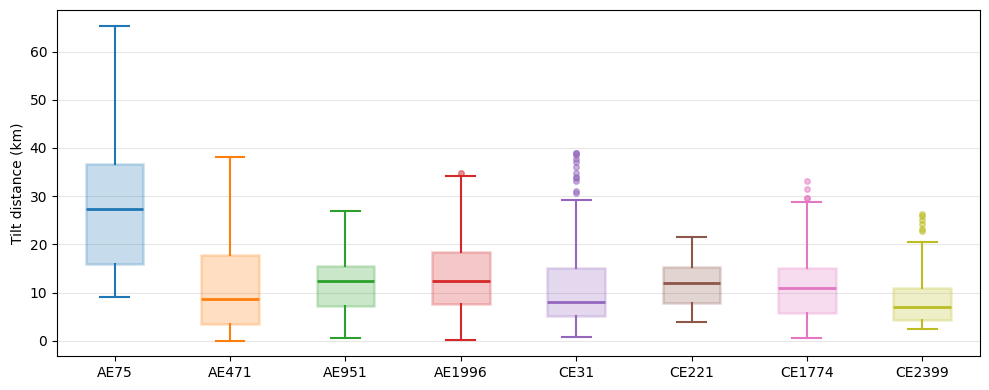

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

data = []
labels = []

for eddy in sample_eddies:
    df_e = df_eddies.loc[df_eddies.Eddy == eddy].copy()

    # print(f'Eddy {eddy}')
    # print(round(df_e.TiltDis.median()))

    Q1 = df_e['TiltDis'].quantile(0.25)
    Q3 = df_e['TiltDis'].quantile(0.75)
    # print(round(Q3 - Q1))
    # print(df_e.TiltDis.min())
    
    x = df_e['TiltDis'].to_numpy()
    x = x[np.isfinite(x)]
    
    cyc = df_e.iloc[0].Cyc
    
    data.append(x)
    labels.append(f'{cyc}{eddy}')

bp = ax.boxplot(
    data,
    tick_labels=labels,
    showfliers=True,
    patch_artist=True
)

# --- Apply consistent AE/CE theme ---
for i in range(len(bp['boxes'])):
    
    c = colors[i]
    
    # Box styling
    bp['boxes'][i].set(
        facecolor=c,
        edgecolor=c,
        alpha=0.25,
        linewidth=1.8
    )
    
    # Median
    bp['medians'][i].set(color=c, linewidth=2)
    
    # Whiskers & caps
    bp['whiskers'][2*i].set(color=c, linewidth=1.5)
    bp['whiskers'][2*i+1].set(color=c, linewidth=1.5)
    bp['caps'][2*i].set(color=c, linewidth=1.5)
    bp['caps'][2*i+1].set(color=c, linewidth=1.5)

    # Outliers (fliers)
    bp['fliers'][i].set(
        marker='o',
        markerfacecolor=c,
        markeredgecolor=c,
        alpha=0.5,
        markersize=4
    )

ax.set_ylabel('Tilt distance (km)')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


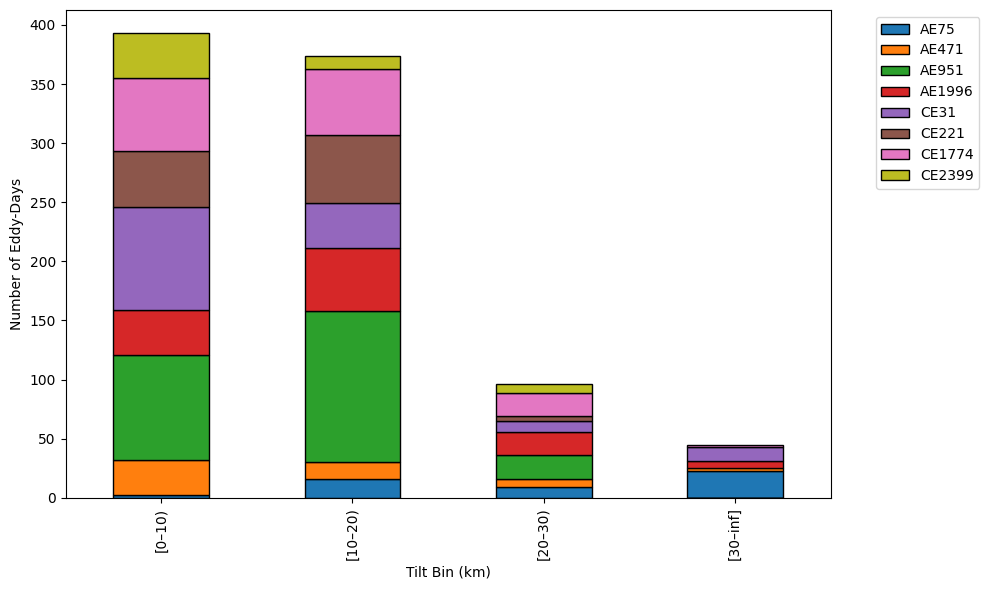

In [9]:
# Adjustable bin width
bin_width = 10  # km
max_depth_km = 40  # adjust as needed

# bins = np.arange(0, max_depth_km + bin_width, bin_width)
bins = [ 0, 10, 20, 30, np.inf]
bin_labels = [f"[{b}–{b+bin_width})" for b in bins[:-2]] \
           + [f"[{bins[-2]}–{bins[-1]}]"]

# Prepare DataFrame
eddies = [int(eddy[4:]) for eddy in list(dic_sample.keys())]
cycs = [df_eddies[df_eddies.Eddy==e].iloc[0].Cyc for e in eddies]
eddy_names = [cycs[k] + str(eddies[k]) for k in range(len(eddies))]

bin_counts = pd.DataFrame(0, index=bin_labels, columns=eddy_names)

for e, eddy in enumerate(sample_eddies):
    df = df_eddies[df_eddies.Eddy == eddy].copy()
    depths = []
    for day in df.Day.unique():
        sub = df[df.Day == day]
        if not sub.empty:
            data = sub.iloc[0]
            depths.append(data.TiltDis)
        else:
            depths.append(np.nan)
    counts, _ = np.histogram(depths, bins=bins)
    cyc = df_eddies[df_eddies.Eddy==eddy].iloc[0].Cyc
    bin_counts.loc[:, f'{cyc}{eddy}'] = counts

# Plot
bin_counts.plot(kind='bar', stacked=True, figsize=(10, 6),
                edgecolor='black', color=colors)
plt.xlabel('Tilt Bin (km)')
plt.ylabel('Number of Eddy-Days')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


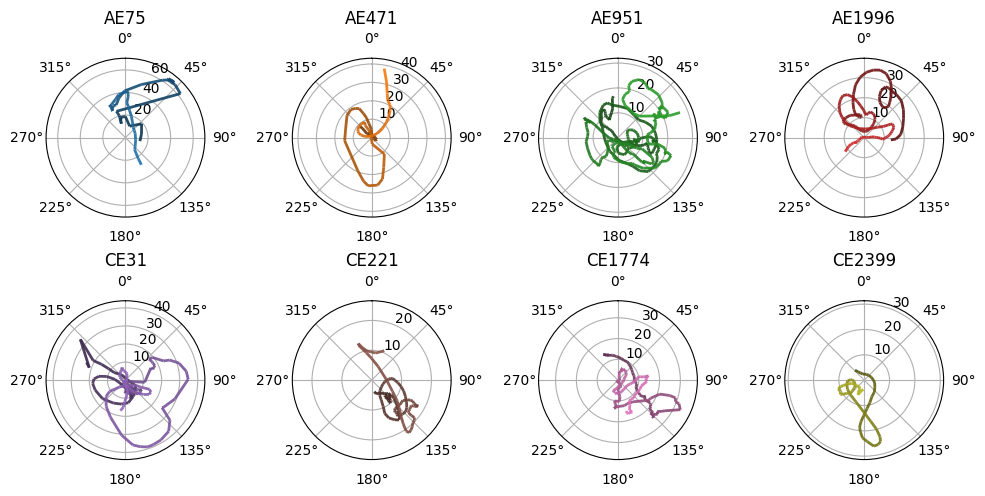

In [10]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

fig, axs = plt.subplots(2, 4, figsize=(10, 5),
                        subplot_kw={'projection': 'polar'})

for e, eddy in enumerate(sample_eddies):
    ax = axs[e // 4, e % 4]
    df = df_eddies[df_eddies.Eddy == eddy]

    r = df.TiltDis.to_numpy()
    theta_deg = df.TiltDir.to_numpy()
    phi = np.deg2rad(theta_deg)

    # build line segments
    points = np.array([phi, r]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # time = each index is a day
    t = np.arange(len(r))

    lc = LineCollection(segments, cmap='Blues', norm=Normalize(vmin=t.min(), vmax=t.max()))
    lc.set_array(t)
    lc.set_linewidth(2)
    lc.set_alpha(0.9)

    # recolour colormap to match base colour
    base = np.array(colors[e])
    cmap = plt.get_cmap('Blues')
    lc.set_cmap(plt.cm.colors.LinearSegmentedColormap.from_list(
        "", [base*0.4, base]
    ))

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.add_collection(lc)

    cyc = df.iloc[0].Cyc
    ax.set_title(f'{cyc}{eddy}')
    ax.set_rlim(0, np.nanmax(r)+5)

plt.tight_layout()
plt.show()
